# Plot raw height distributions of monolayer and rescaled distribution

In [42]:
import sys
import json
import numpy as np
import seaborn as sns
import scipy.stats as stats 
import matplotlib  as mpl
import matplotlib.pyplot as plt


from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter

sys.path.append("scripts/utils/")
from file_operations import load_stack
from SegmentedCells  import SegmentedCells
from averaging_functions import compute_pdf_from_bins
from Microscopes import Holomonitor, Tomocube

In [43]:
# Paths
data_path = "../../../../hdd_data/silja/Monolayers/"

In [44]:
lw = 8
cmap = "Blues_r"
measure = "pixel"
dataset = "MDCK_2025-02-10_A2-1"
# delta = -1
# gamma = 1.33

## Load data

In [ ]:
config = json.load(open(f"configs/{dataset}.json"))
h_pix  = load_stack(f"{data_path}height_fields/calibrated/{dataset}/", config, data_type="cells")
h_pix  = load_stack(f"{data_path}ri_fields/calibrated/{dataset}/",     config, data_type="cells")

cells   = SegmentedCells(f"{data_path}cell_features/calibrated/{dataset}_cells.p")
density = cells.density.astype("int")

microscope = config["microscope"]

### SET MICROSCOPE ###
if config['microscope'] == "holomonitor": microscope = Holomonitor()
elif config['microscope'] == "tomocube":  microscope = Tomocube()

State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_2025-02-10_A2-1_cells.p.


### Apply Gaussian filter

In [46]:
if measure == "disc":   
    
    h_disc = []
    for h, rho in zip(h_pix, cells.density):

        A_mean = 1/(rho / 10**6)
        r_mean = np.sqrt(A_mean / np.pi)
        sigma  = microscope.rblur * r_mean / microscope.pix_to_um

        # Apply Gaussian blur to data
        h_disc.append(gaussian_filter(h, sigma))

    h_disc = np.array(h_disc)

In [47]:
density_bin = 100

# Define range of cell densities to bin data by
min_density = 100 * int(min(density) / 100)
max_density = 100 * int(max(density) / 100)
binned_density = np.arange(min_density, max_density + density_bin, density_bin)

In [48]:
height_distribution = []

Nbins = len(binned_density) - 1
for i in range(Nbins):
        
    # define low and high boundary on bin
    low_lim  = binned_density[i]   #min_density + args.bin_size * i
    high_lim = binned_density[i+1] #min_density + args.bin_size *(i+1)
    
    # mask relevant densities
    density_mask = (density >= low_lim) * (density < high_lim)

    if measure == "disc":
        heights_in_bin = h_disc[density_mask]
    else:
        heights_in_bin = h_pix[density_mask]
    height_distribution.append(heights_in_bin.ravel())


In [49]:
y_pdf = []
x_pdf = []
sigma = 1

for h in height_distribution:
    # h = h * gamma + delta
    h = h[h>0]
    h_x, h_y = compute_pdf_from_bins(h, 3, sigma=sigma)

    y_pdf.append(h_y)
    x_pdf.append(h_x)

[Text(0.5, 0, 'h (µm)'), Text(0, 0.5, 'PDF')]

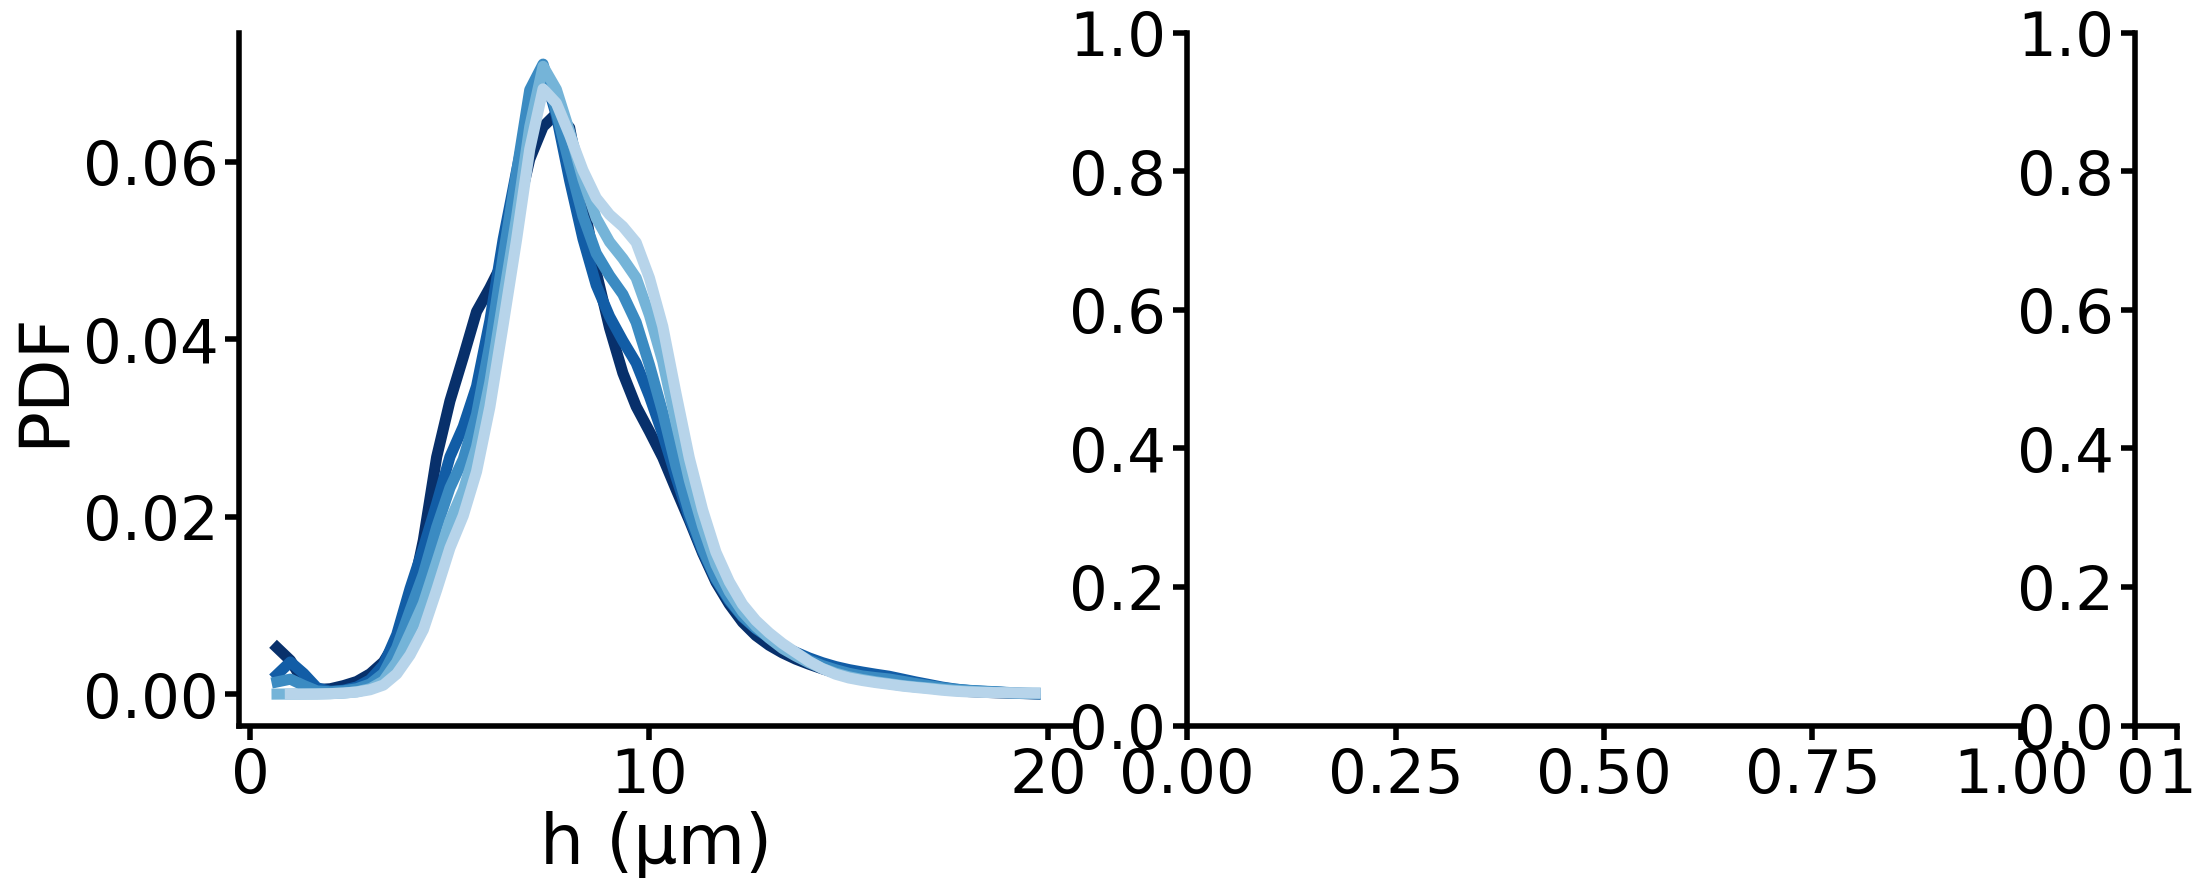

In [50]:
# Plot
font  = {'size': 50}
lines = {'lw' : 4}
axes  = {'lw' : 4}
mpl.rc('font', **font)
mpl.rc('lines', **lines)
mpl.rc('axes', **axes)
mpl.rc('xtick.major', size = 10, pad = 5, width=4)
mpl.rc('ytick.major', size = 10, pad = 5, width=4)
mpl.rc('xtick', labelsize=44)
mpl.rc('ytick', labelsize=44)



colors = mpl.colormaps[cmap](np.linspace(0, 0.7, len(x_pdf)))
fig, ax = plt.subplots(1, 3, figsize=(25,9), gridspec_kw={'width_ratios': [1, 1, 0.05]})
# fig, ax = plt.subplots(1, 3, figsize=(19,7.5), gridspec_kw={'width_ratios': [1, 1, 0.1]})

for i in range(0, len(x_pdf), 2):
    mask = x_pdf[i] < 20

    ax[0].plot(x_pdf[i][mask], y_pdf[i][mask], c=colors[i], lw=lw)


sns.despine(fig)
ax[0].set(xlabel=r"h (µm)", ylabel=r"PDF")
# ax[0].set_xticks([0, 5, 10, 15, 20]);
# ax[0].set(xlim=(-0.5, 16))

## Plot rescaled distribution

In [51]:
y_pdf_rescaled = []
x_pdf_rescaled = []

for h in height_distribution:
    # h = h * gamma + delta
    h = h[h>0]
    h_x, h_y = compute_pdf_from_bins(h / np.mean(h), 100, sigma=0)


    y_pdf_rescaled.append(h_y)
    x_pdf_rescaled.append(h_x)


# smoothen data a little
y_pdf_smooth = []

for y in y_pdf_rescaled:
    y_pdf_smooth.append(gaussian_filter(y, sigma=2))

Gamma
Shape parameter:  15.029 +/- 0.045
Scale parameter:  0.0659232 +/- 0.0000009
Chi2: 0.0187

Log-normal
Shape parameter: 0.262 +/- 0.000
Scale parameter: 0.9755364 +/- 0.0000057
Chi2: 0.0229


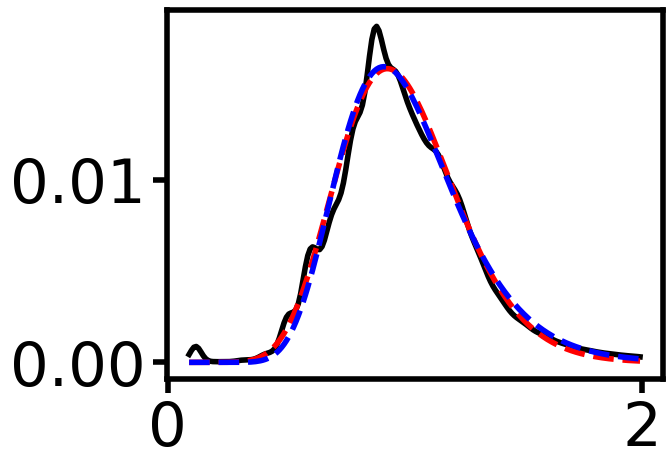

In [52]:
# Fit Gamma distribution to data
if measure == "disc":
    xlim = 2
elif measure == "pixel":
    xlim = 2

# Define function
def gamma_distribution(x, a, scale):
    gamma = stats.gamma.pdf(x, a, scale=scale)
    return gamma / np.sum(gamma)

def lognorm_distribution(x, a, scale):
    lognorm = stats.lognorm.pdf(x, a, scale=scale)
    #lognorm = stats.t.pdf(x, a, scale=scale)
    return lognorm / np.sum(lognorm)

# Compute mean distribution
x_mean = np.ma.array([x[x<xlim] for x in x_pdf_rescaled])
y_mean = np.ma.array([y[x<xlim] for x, y in zip(x_pdf_rescaled, y_pdf_smooth)])
x_mean = np.ma.mean(x_mean, axis=0)
y_mean = np.ma.mean(y_mean, axis=0)

# i = 4
# x_mean = x_pdf_rescaled[i]
# y_mean = y_pdf_smooth[i]

# Fit
if measure == "pixel":
    g_params, g_popt = curve_fit(gamma_distribution, x_mean, y_mean, p0=[8, 0.12])
    gamma = gamma_distribution(x_mean, *g_params)

    l_params, l_popt = curve_fit(lognorm_distribution, x_mean, y_mean, p0=[8, 0.12])
    lognorm = lognorm_distribution(x_mean, *l_params)

elif measure == "disc":
    g_params, g_popt = curve_fit(gamma_distribution, x_mean, y_mean, p0=[24, 0.045])
    gamma = gamma_distribution(x_mean, *g_params)

    l_params, l_popt = curve_fit(lognorm_distribution, x_mean, y_mean, p0=[0.1,0.1])# p0=[0.2, 1])
    lognorm = lognorm_distribution(x_mean, *l_params)


# Plot
plt.plot(x_mean, y_mean, 'k')
plt.plot(x_mean, gamma, 'r--')
plt.plot(x_mean, lognorm, 'b--')
plt.yscale("linear")

print("Gamma")
print(f"Shape parameter:  {g_params[0]:0.3f} +/- {g_popt[0,0]:0.3f}")
print(f"Scale parameter:  {g_params[1]:0.7f} +/- {g_popt[1,1]:0.7f}")
print(f"Chi2: {np.sum((gamma - y_mean)**2 / y_mean):0.4f}")

print("\nLog-normal")
print(f"Shape parameter: {l_params[0]:0.3f} +/- {l_popt[0,0]:0.3f}")
print(f"Scale parameter: {l_params[1]:0.7f} +/- {l_popt[1,1]:0.7f}")
print(f"Chi2: {np.sum((lognorm - y_mean)**2 / y_mean):0.4f}")

In [53]:
# Plot
colors = mpl.colormaps[cmap](np.linspace(0, 0.7, 10))

#create plot of Gamma distribution
gamma   = gamma_distribution(x_mean,   *g_params)
lognorm = lognorm_distribution(x_mean, *l_params)
#plt.plot(x_mean[mask], gamma[mask], 'r--', lw=6, alpha=0.5)


fig.subplots_adjust(left=1/7,
                    right=0.995,
                    bottom=1.1/5,
                    top=0.995,
                    wspace=0.3)


for i in range(0, len(x_pdf_rescaled), 2):
    mask = (x_pdf_rescaled[i] < xlim)*(y_pdf_smooth[i] > 1e-4)
    sum = np.ma.sum(y_pdf_smooth[i][mask])
    ax[1].plot(x_pdf_rescaled[i][mask], y_pdf_smooth[i][mask], c=colors[i], lw=lw)

mask = (gamma > 1e-4)
ax[1].plot(x_mean[mask], gamma[mask], '--', color="red", lw=lw+2, alpha=0.9)

mask = (lognorm > 1e-4)
ax[1].plot(x_mean[mask], lognorm[mask], '-.', color="k", lw=lw+2, alpha=1)


#sns.despine(fig)
ax[1].set(xlabel=r"h / $\langle$h$\rangle$")
ax[1].set(yscale="log")

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

norm = Normalize(vmin=binned_density.min(), vmax=binned_density.max())
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # required only for older Matplotlib versions

# Attach one colorbar to the whole figure; 'ax' can be a list of axes
cbar = fig.colorbar(sm, cax=ax[2])#, fraction=0.046, pad=0.02)
cbar.set_label(r"cells/mm$^{2}$")

fig.tight_layout()

ax[1].set_xticks([0, 1, 2])
# fig.tight_layout()
# fig.savefig(f"figs/Elife/subfigures/{measure}wise_height_distribution.svg")


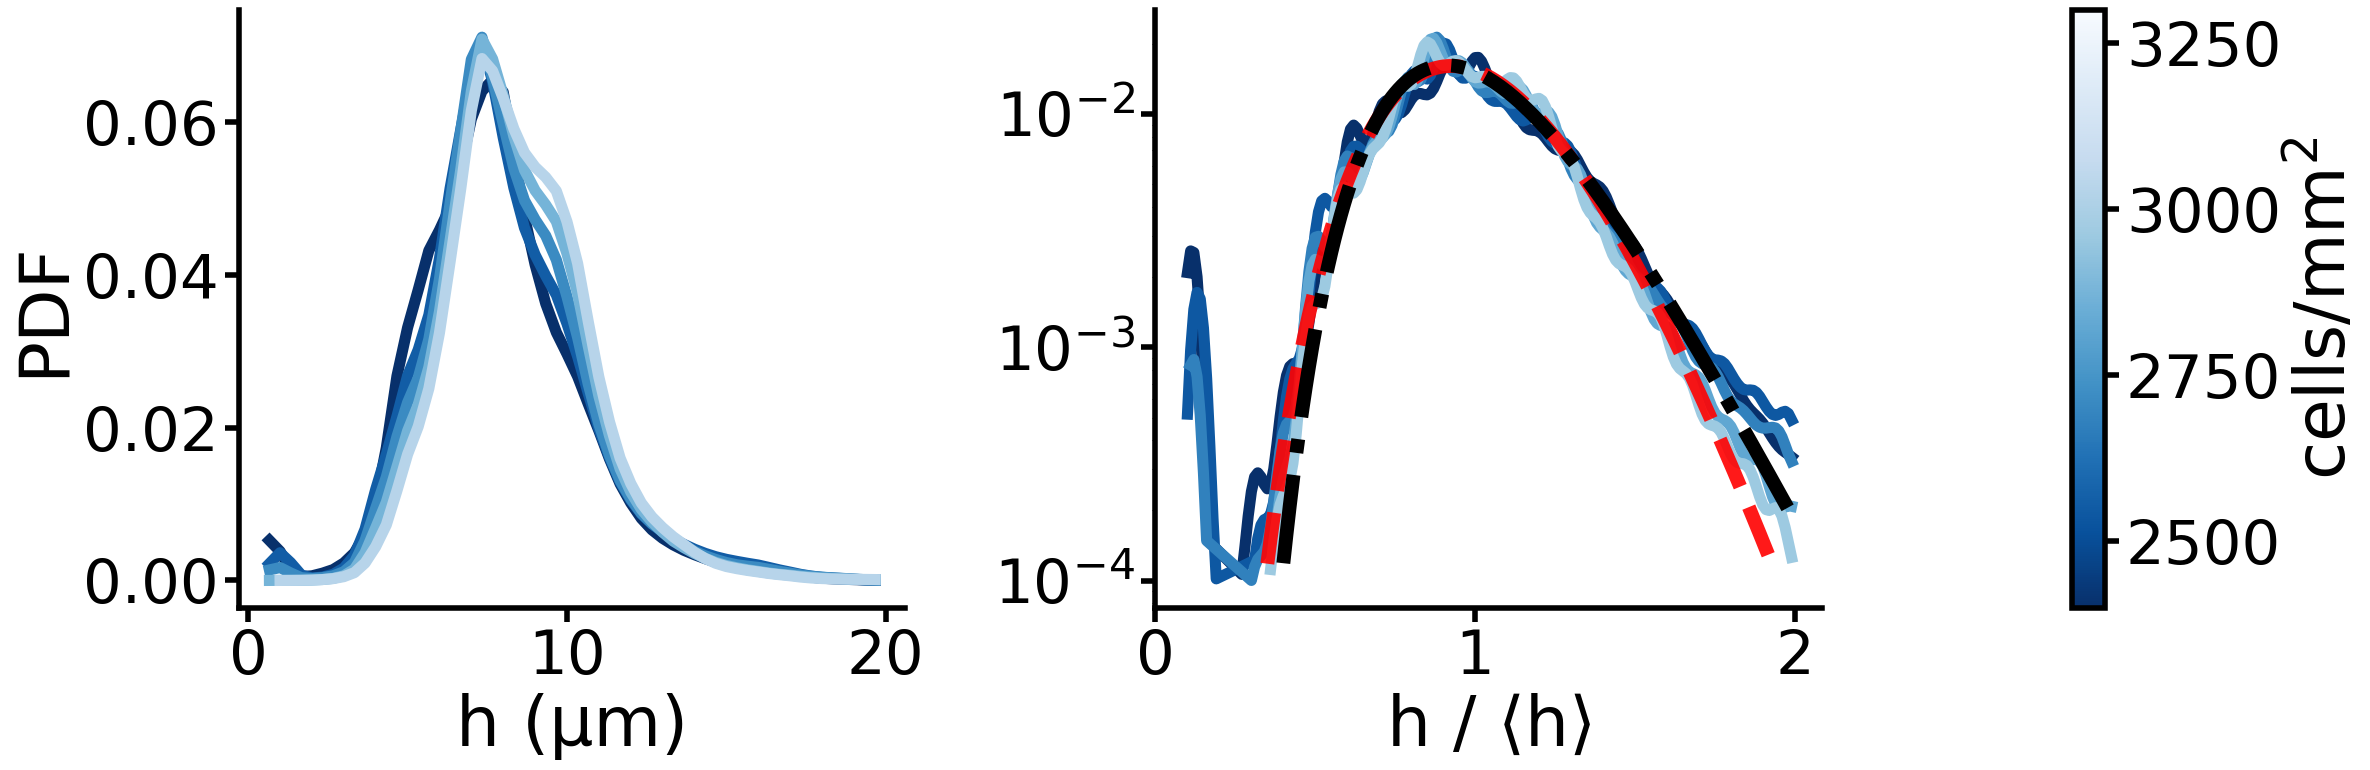

In [54]:
fig